<a href="https://colab.research.google.com/github/GrSonny/lock-in/blob/main/GuptasCodeforProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Loading data


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
df=pd.read_csv('gdrive/My Drive/plant_data.csv')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

# This shows how moisture, temperature, and humidity change over time.


In [ ]:
# Filter Plant 1
plant1 = df[df['plant_id'] == 1].copy()
plant1 = plant1.sort_values("timestamp")

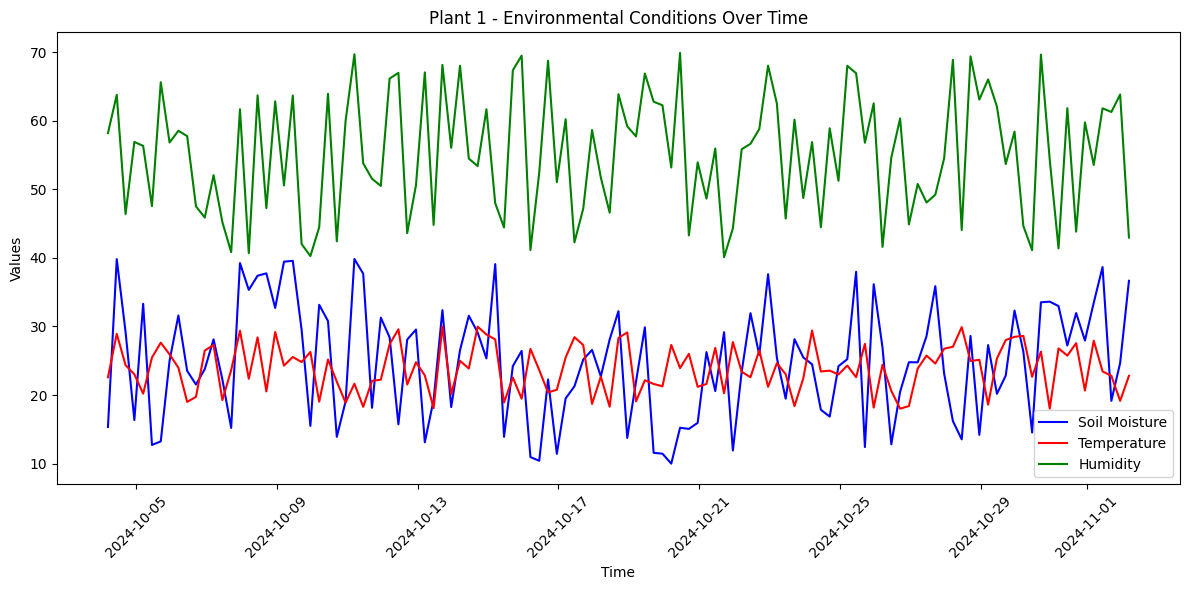

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(plant1['timestamp'], plant1['soil_moisture'],
         color='blue', label='Soil Moisture')

plt.plot(plant1['timestamp'], plant1['temperature'],
         color='red', label='Temperature')

plt.plot(plant1['timestamp'], plant1['humidity'],
         color='green', label='Humidity')

plt.title("Plant 1 - Environmental Conditions Over Time")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1. Blue spikes (Soil Moisture high) → Plant was watered.

2. Sharp drop after spike → Soil drying naturally.

3. Temperature remains relatively stable.

4. Humidity fluctuates moderately.

# Moisture Highlight Plot (Watering Detection)


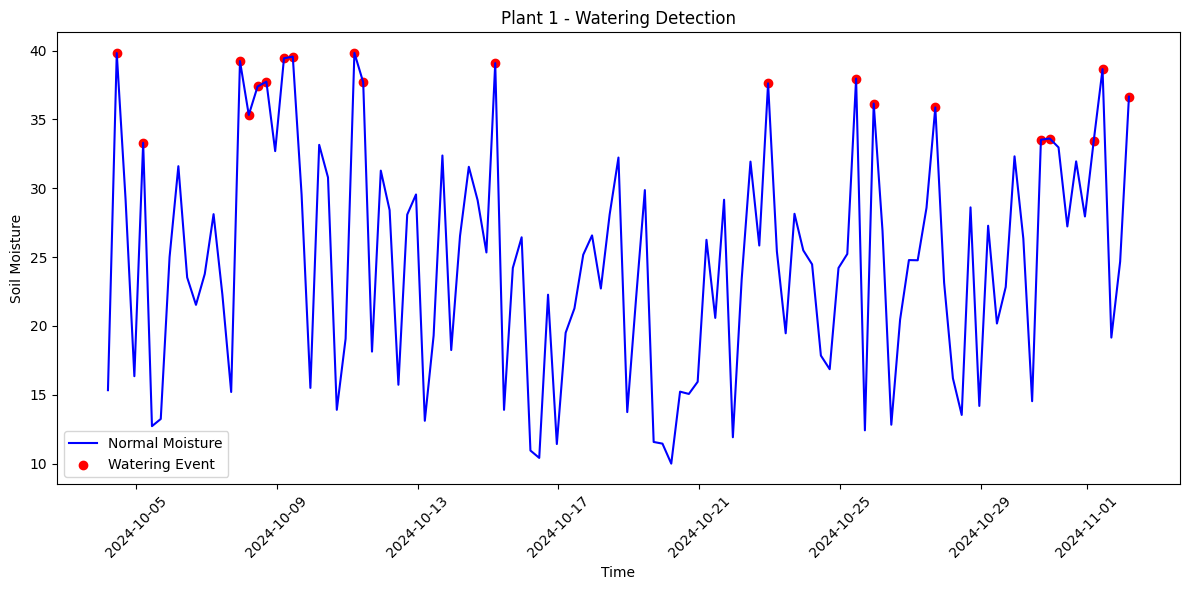

In [ ]:
# high moisture threshold
threshold = plant1['soil_moisture'].mean() + plant1['soil_moisture'].std()

plt.figure(figsize=(12,6))

# Normal moisture
plt.plot(plant1['timestamp'], plant1['soil_moisture'],
         color='blue', label='Normal Moisture')

# High moisture (watering events)
high_moisture = plant1[plant1['soil_moisture'] > threshold]

plt.scatter(high_moisture['timestamp'],
            high_moisture['soil_moisture'],
            color='red', label='Watering Event')

plt.title("Plant 1 - Watering Detection")
plt.xlabel("Time")
plt.ylabel("Soil Moisture")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1. Red dots = watering events.

# Relationship Between Moisture & Temperature


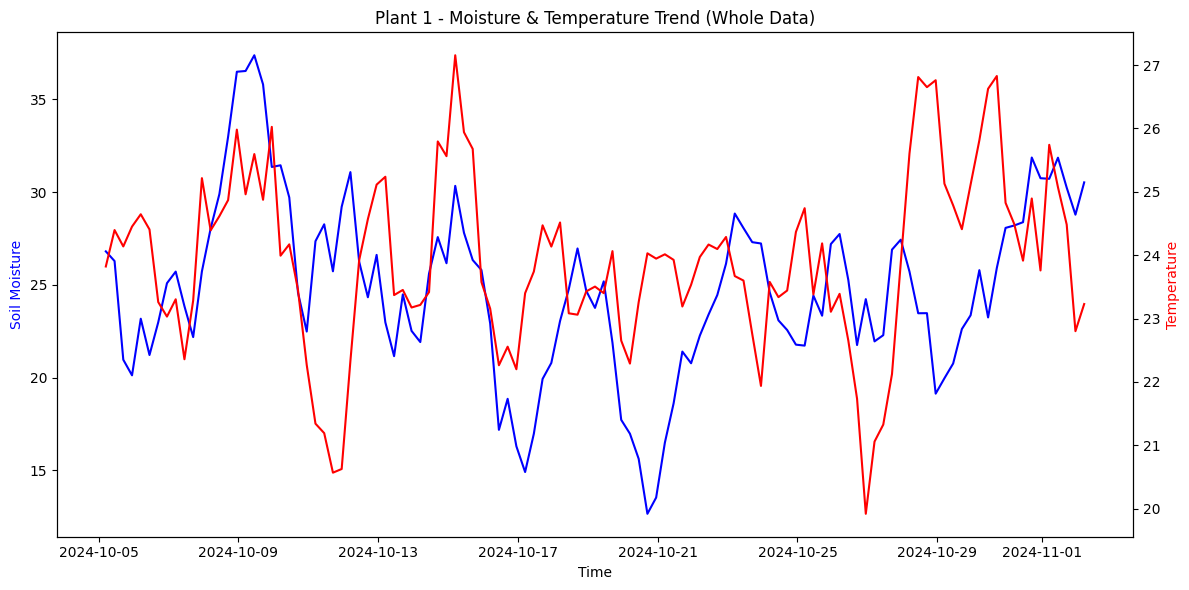

In [ ]:
plant1['moisture_roll'] = plant1['soil_moisture'].rolling(window=5).mean()
plant1['temp_roll'] = plant1['temperature'].rolling(window=5).mean()

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(plant1['timestamp'],
         plant1['moisture_roll'],
         color='blue',
         label='Soil Moisture (Smoothed)')

ax1.set_xlabel("Time")
ax1.set_ylabel("Soil Moisture", color='blue')

ax2 = ax1.twinx()
ax2.plot(plant1['timestamp'],
         plant1['temp_roll'],
         color='red',
         label='Temperature (Smoothed)')

ax2.set_ylabel("Temperature", color='red')

plt.title("Plant 1 - Moisture & Temperature Trend (Whole Data)")
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

1. Temperature increases → moisture decreases

# Humidity vs Moisture


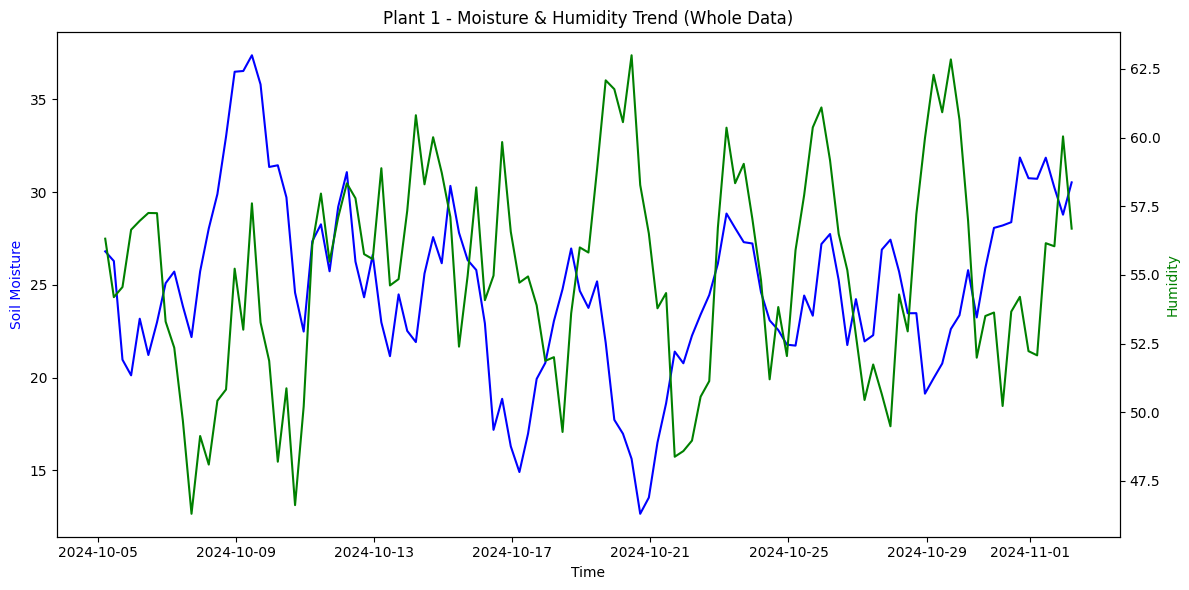

In [ ]:
plant1['humidity_roll'] = plant1['humidity'].rolling(window=5).mean()

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(plant1['timestamp'],
         plant1['moisture_roll'],
         color='blue',
         label='Soil Moisture (Smoothed)')

ax1.set_xlabel("Time")
ax1.set_ylabel("Soil Moisture", color='blue')

ax2 = ax1.twinx()
ax2.plot(plant1['timestamp'],
         plant1['humidity_roll'],
         color='green',
         label='Humidity (Smoothed)')

ax2.set_ylabel("Humidity", color='green')

plt.title("Plant 1 - Moisture & Humidity Trend (Whole Data)")
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

1. Higher humidity may slow drying.

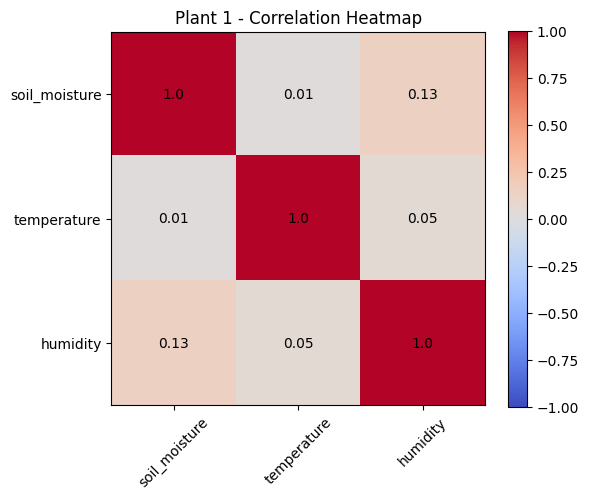

In [ ]:
data = plant1[['soil_moisture', 'temperature', 'humidity']]

corr = data.corr()

plt.figure(figsize=(6,5))

# Create heatmap
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

# Add color bar
plt.colorbar(im)

# Add labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values inside boxes
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i,
                 round(corr.iloc[i, j], 2),
                 ha='center', va='center',
                 color='black')

plt.title("Plant 1 - Correlation Heatmap")
plt.tight_layout()
plt.show()

As this is a house plant correlation shows that temperature and humidity does not have strong relationship with soil moisture. Soil moisture is basically maintained by watering.